In [9]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

API_KEY = "94DDBB52-2444-4E86-A7C7-16D20A22F6C3"

region_map = {
    '10': '한강',
    '11': '안성천',
    '12': '한강서해',
    '13': '한강동해'
}

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'

# ── 관측소 코드 추출 (담당 권역만) ───────────────────────────────────────────
url = f"https://api.hrfco.go.kr/{API_KEY}/waterlevel/list/1H.xml"
response = requests.get(url, timeout=30, verify=False)
root = ET.fromstring(response.text)

obscd_list = list(set([
    item.findtext('wlobscd')
    for item in root.findall('.//Waterlevel')
    if item.findtext('wlobscd') is not None
]))

# 안성천(11), 한강서해(12), 한강동해(13)
target_obscd = [code for code in obscd_list if code[:2] in ['11','12','13']]
print(f"대상 관측소 수: {len(target_obscd)}개")

# ── 연도별 7/8월 1H 수위 수집 ────────────────────────────────────────────────
periods = [
    ("2024070100", "2024083100", "2024"),  # HH까지만
    ("2025070100", "2025083100", "2025"),
]

for start, end, year_label in periods:
    print(f"\n{year_label} 7/8월 1H 수집 시작...")
    all_data = []

    for i, obscd in enumerate(target_obscd):
        url = (
            f"https://api.hrfco.go.kr/{API_KEY}"
            f"/waterlevel/list/1H/{obscd}/{start}/{end}.xml"
        )
        try:
            res = requests.get(url, timeout=30, verify=False)
            root = ET.fromstring(res.text)
            for item in root.findall('.//Waterlevel'):
                wl_val = item.findtext('wl')
                if wl_val is None or not wl_val.strip() or wl_val.strip() in ('-', ''):
                   continue
                all_data.append({
                    'obscd':    item.findtext('wlobscd'),
                    'region':   region_map.get(item.findtext('wlobscd', '')[:2], '기타'),
                    'datetime': item.findtext('ymdhm'),
                    'wl':       float(wl_val),
                    'fw':       item.findtext('fw'),
                })
        except Exception as e:
            print(f"  ⚠ {obscd} 오류: {e}")
        time.sleep(0.1)

        if i % 10 == 0:
            print(f"  진행중... {i}/{len(target_obscd)}")

    df = pd.DataFrame(all_data)
    df['datetime'] = pd.to_datetime(df['datetime'], format='%Y%m%d%H')
    df = df.sort_values(['obscd','datetime']).reset_index(drop=True)

    save_path = f'{base}\\waterlevel_1H_{year_label}_78.csv'
    df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"✅ {year_label} 저장 완료! ({len(df):,}행)")

대상 관측소 수: 54개

2024 7/8월 1H 수집 시작...
  진행중... 0/54
  진행중... 10/54
  진행중... 20/54
  진행중... 30/54
  진행중... 40/54
  진행중... 50/54
✅ 2024 저장 완료! (49,778행)

2025 7/8월 1H 수집 시작...
  진행중... 0/54
  진행중... 10/54
  진행중... 20/54
  진행중... 30/54
  진행중... 40/54
  진행중... 50/54
✅ 2025 저장 완료! (76,172행)


In [10]:
df = pd.read_csv(r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
print(df.head(20))

      obscd region             datetime    wl    fw
0   1101605    안성천  2024-07-01 00:00:00  1.68  4.59
1   1101605    안성천  2024-07-01 01:00:00  1.68  4.59
2   1101605    안성천  2024-07-01 02:00:00  1.67  4.34
3   1101605    안성천  2024-07-01 03:00:00  1.65  3.87
4   1101605    안성천  2024-07-01 04:00:00  1.64  3.64
5   1101605    안성천  2024-07-01 05:00:00  1.64  3.64
6   1101605    안성천  2024-07-01 06:00:00  1.62  3.21
7   1101605    안성천  2024-07-01 07:00:00  1.61  3.01
8   1101605    안성천  2024-07-01 08:00:00  1.60  2.81
9   1101605    안성천  2024-07-01 09:00:00  1.60  2.81
10  1101605    안성천  2024-07-01 10:00:00  1.60  2.81
11  1101605    안성천  2024-07-01 11:00:00  1.62  3.21
12  1101605    안성천  2024-07-01 12:00:00  1.64  3.64
13  1101605    안성천  2024-07-01 13:00:00  1.64  3.64
14  1101605    안성천  2024-07-01 14:00:00  1.64  3.64
15  1101605    안성천  2024-07-01 15:00:00  1.64  3.64
16  1101605    안성천  2024-07-01 16:00:00  1.64  3.64
17  1101605    안성천  2024-07-01 17:00:00  1.64  3.64
18  1101605 

In [11]:
print(df['obscd'].unique()[:5])

[1101605 1101609 1101610 1101615 1101618]


In [12]:
import pandas as pd
import numpy as np

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'

# ── 1H 데이터 로드 ────────────────────────────────────────────────────────────
df_24 = pd.read_csv(f'{base}\\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
df_25 = pd.read_csv(f'{base}\\waterlevel_1H_2025_78.csv', encoding='utf-8-sig')

df_24['year'] = 2024
df_25['year'] = 2025
df_1h = pd.concat([df_24, df_25], ignore_index=True)
df_1h['datetime'] = pd.to_datetime(df_1h['datetime'])
df_1h['wl'] = pd.to_numeric(df_1h['wl'], errors='coerce')
df_1h = df_1h.dropna(subset=['wl'])

# ── obsFinal merge (하천명, 해발수위, 특보여부) ───────────────────────────────
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')

stream_map = {
    '평택수위표':    '안성천',
    '동연교수위표':  '진위천',
    '안성천상류':    '안성천',
    '황구지천상류':  '황구지천',
    '황구지천하류':  '황구지천',
    '아산방조제상류': '안성천',
    '이동댐':        '진위천',
    '삼척오십천상류': '삼척오십천',
    '삼천오십천하류': '삼척오십천',
}
df_meta['korStream_x'] = df_meta['korStream_x'].replace(stream_map)
df_meta['waterElevation'] = pd.to_numeric(df_meta['waterElevation'], errors='coerce')
df_meta['is_special'] = np.where(df_meta['aFLAdvisory(m)'] == '-', 0, 1)

# merge
df_1h = df_1h.merge(
    df_meta[['codeObs','korObs','korStream_x','sphereLarge','waterElevation','is_special']],
    left_on='obscd', right_on='codeObs', how='left'
)

# ── 관측소별 연도별 피크 탐지 ─────────────────────────────────────────────────
peaks = df_1h.groupby(['year','obscd'])['wl'].idxmax()
df_peaks = df_1h.loc[peaks][['year','obscd','korObs','korStream_x',
                               'sphereLarge','waterElevation',
                               'is_special','datetime','wl']].reset_index(drop=True)
df_peaks = df_peaks.rename(columns={'datetime':'peak_datetime', 'wl':'peak_wl'})
df_peaks = df_peaks.sort_values(['sphereLarge','korStream_x','waterElevation','year'],
                                 ascending=[True,True,False,True])

print(df_peaks.to_string())
df_peaks.to_csv(f'{base}\\peak_dates.csv', index=False, encoding='utf-8-sig')
print("\n✅ 피크 날짜 저장 완료!")

    year    obscd      korObs korStream_x sphereLarge  waterElevation  is_special       peak_datetime  peak_wl
48  2025  1101631    천안시(장천교)         성환천         안성천            9.88         0.0 2025-07-17 08:00:00     6.03
2   2024  1101610   안성시(옥산대교)         안성천         안성천           18.38         0.0 2024-07-18 13:00:00     2.30
38  2025  1101610   안성시(옥산대교)         안성천         안성천           18.38         0.0 2025-07-17 09:00:00     2.21
5   2024  1101620    안성시(건천리)         안성천         안성천            8.27         0.0 2024-07-18 14:00:00     4.50
43  2025  1101620    안성시(건천리)         안성천         안성천            8.27         0.0 2025-07-17 09:00:00     4.34
8   2024  1101630   천안시(안성천교)         안성천         안성천            3.84         0.0 2024-07-18 16:00:00     4.22
47  2025  1101630   천안시(안성천교)         안성천         안성천            3.84         0.0 2025-07-17 10:00:00     4.96
57  2025  1101688    아산시(운교교)         안성천         안성천            3.37         0.0 2025-07-17 07:00:00     6.30
9

In [15]:
# 관측소별 연도 개수 확인
df_1h.groupby('obscd')['year'].nunique().value_counts()

year
2    34
1    18
Name: count, dtype: int64

In [22]:
pip install dtaidistance

Note: you may need to restart the kernel to use updated packages.Collecting dtaidistance
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------------- ---------- 1.0/1.4 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 6.7 MB/s eta 0:00:00




[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


황구지천: 수원시(매세교) → 수원시(백년교) | DTW: 0.683 | 시차: 0.0h
황구지천: 수원시(백년교) → 화성시(화산교) | DTW: 1.0041 | 시차: 1.0h
황구지천: 화성시(화산교) → 화성시(수직교) | DTW: 0.5194 | 시차: 2.0h
안성천: 안성시(옥산대교) → 안성시(건천리) | DTW: 0.4025 | 시차: 0.0h
안성천: 안성시(건천리) → 천안시(안성천교) | DTW: 0.3061 | 시차: 1.0h
안성천: 천안시(안성천교) → 아산시(운교교) | DTW: 0.3727 | 시차: -2.0h
안성천: 아산시(운교교) → 평택시(군문교) | DTW: 0.6062 | 시차: 3.0h
안성천: 평택시(군문교) → 평택시(팽성대교) | DTW: 2.0906 | 시차: 0.0h
한천: 안성시(평촌교) → 안성시(한천교) | DTW: 0.6961 | 시차: 1.0h
진위천: 용인시(덕성1교) → 용인시(전궁교) | DTW: 2.459 | 시차: 0.0h
진위천: 용인시(전궁교) → 평택시(진위1교) | DTW: 0.5071 | 시차: 3.0h
진위천: 평택시(진위1교) → 평택시(회화리) | DTW: 0.2952 | 시차: 0.5h
진위천: 평택시(회화리) → 평택시(동연교) | DTW: 0.7282 | 시차: 1.0h
양양남대천: 양양군(용천2교) → 양양군(양양대교) | DTW: 1.404 | 시차: 0.0h
강릉남대천: 강릉시(오봉교) → 강릉시(회산교) | DTW: 1.7278 | 시차: 3.0h
연곡천: 강릉시(우정교) → 강릉시(송림교) | DTW: 2.8826 | 시차: 10.0h
삼척오십천: 삼척시(전두3교) → 삼척시(상정교) | DTW: 1.7029 | 시차: 8.0h
삼척오십천: 삼척시(상정교) → 삼척시(오십천교) | DTW: 3.1124 | 시차: -29.5h
청초천: 속초시(도문교) → 속초시(응골교) | DTW: 4.6085 | 시차: 1.0h


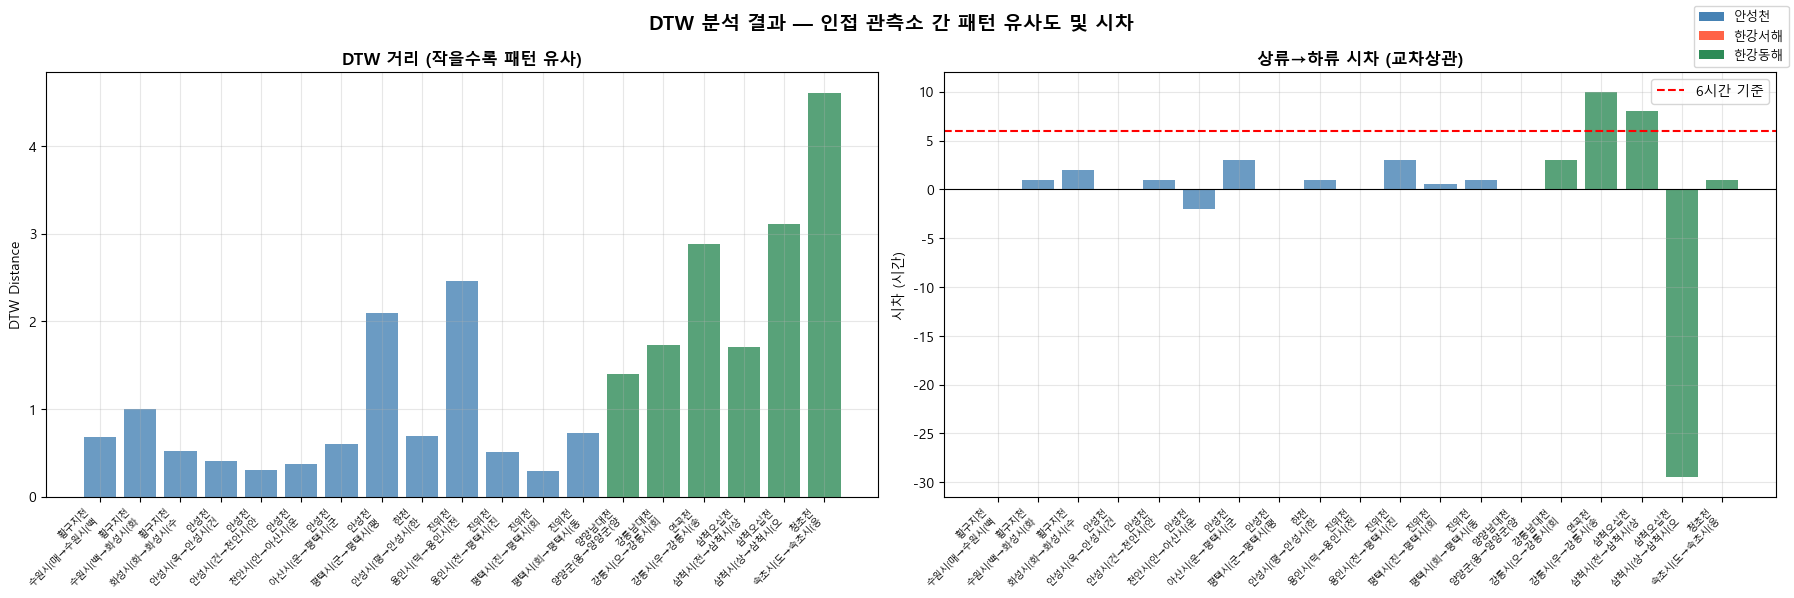


✅ DTW 완료!


In [36]:
#2024+2025 데이터로 DTW+교차상관 (인접 관측소 비교)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from dtaidistance import dtw
from scipy.signal import correlate

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df_24 = pd.read_csv(f'{base}\\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
df_25 = pd.read_csv(f'{base}\\waterlevel_1H_2025_78.csv', encoding='utf-8-sig')
df_1h = pd.concat([df_24, df_25], ignore_index=True)
df_1h['datetime'] = pd.to_datetime(df_1h['datetime'])
df_1h['wl'] = pd.to_numeric(df_1h['wl'], errors='coerce')
df_1h = df_1h.dropna(subset=['wl'])

df_peaks = pd.read_csv(f'{base}\\peak_dates.csv', encoding='utf-8-sig')
df_peaks['peak_datetime'] = pd.to_datetime(df_peaks['peak_datetime'])

# obsFinal merge
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')
stream_map = {
    '평택수위표': '안성천', '동연교수위표': '진위천',
    '안성천상류': '안성천', '황구지천상류': '황구지천',
    '황구지천하류': '황구지천', '아산방조제상류': '안성천',
    '이동댐': '진위천', '삼척오십천상류': '삼척오십천',
    '삼천오십천하류': '삼척오십천',
}
df_meta['korStream_x'] = df_meta['korStream_x'].replace(stream_map)
df_meta['waterElevation'] = pd.to_numeric(df_meta['waterElevation'], errors='coerce')
df_meta['is_special'] = np.where(df_meta['aFLAdvisory(m)'] == '-', 0, 1)

df_1h = df_1h.merge(
    df_meta[['codeObs','korObs','korStream_x','sphereLarge','waterElevation','is_special']],
    left_on='obscd', right_on='codeObs', how='left'
)

# ── DTW 분석 (인접 관측소) ────────────────────────────────────────────────────
target_regions = ['안성천', '한강서해', '한강동해']
results = []

for region in target_regions:
    df_region = df_1h[df_1h['sphereLarge'] == region]
    streams = df_region['korStream_x'].dropna().unique()

    for stream in streams:
        df_stream = df_region[df_region['korStream_x'] == stream]

        obs_sorted = (df_meta[df_meta['korStream_x'] == stream]
                      .sort_values('waterElevation', ascending=False)['codeObs'].tolist())
        obs_in_data = [o for o in obs_sorted if o in df_stream['obscd'].values]

        if len(obs_in_data) < 2:
            continue

        # 인접 관측소끼리 비교
        for i in range(len(obs_in_data) - 1):
            ref_obs = obs_in_data[i]      # 상류
            tgt_obs = obs_in_data[i + 1]  # 바로 아래 하류

            ref_name = df_meta[df_meta['codeObs']==ref_obs]['korObs'].values[0]
            tgt_name = df_meta[df_meta['codeObs']==tgt_obs]['korObs'].values[0]

            dtw_distances = []
            lag_hours_list = []

            for _, pk_row in df_peaks[df_peaks['obscd'] == ref_obs].iterrows():
                peak_dt = pk_row['peak_datetime']
                start_dt = peak_dt - pd.Timedelta(days=3)
                end_dt   = peak_dt + pd.Timedelta(days=5)

                ref_w = (df_stream[df_stream['obscd'] == ref_obs]
                         .set_index('datetime')
                         .reindex(pd.date_range(start_dt, end_dt, freq='1H'))['wl']
                         .interpolate().values)

                tgt_w = (df_stream[df_stream['obscd'] == tgt_obs]
                         .set_index('datetime')
                         .reindex(pd.date_range(start_dt, end_dt, freq='1H'))['wl']
                         .interpolate().values)

                mask = ~(np.isnan(ref_w) | np.isnan(tgt_w))
                ref_s = ref_w[mask].astype(np.float64)
                tgt_s = tgt_w[mask].astype(np.float64)

                if len(ref_s) < 10:
                    continue

                # 정규화
                ref_norm = (ref_s - ref_s.min()) / (ref_s.max() - ref_s.min() + 1e-9)
                tgt_norm = (tgt_s - tgt_s.min()) / (tgt_s.max() - tgt_s.min() + 1e-9)

                # DTW 거리
                dist = dtw.distance(ref_norm, tgt_norm)
                dtw_distances.append(dist)

                # 교차상관 시차
                corr = correlate(tgt_s - tgt_s.mean(), ref_s - ref_s.mean(), mode='full')
                lag_steps = corr.argmax() - (len(ref_s) - 1)
                lag_hours_list.append(lag_steps)

            if not dtw_distances:
                continue

            avg_dist = round(np.mean(dtw_distances), 4)
            avg_lag  = round(np.mean(lag_hours_list), 2)

            results.append({
                'region':     region,
                'stream':     stream,
                'upstream':   ref_name,
                'downstream': tgt_name,
                'dtw_dist':   avg_dist,
                'lag_hours':  avg_lag,
                'n_events':   len(dtw_distances),
            })
            print(f"{stream}: {ref_name} → {tgt_name} | DTW: {avg_dist} | 시차: {avg_lag}h")

# ── 저장 및 시각화 ────────────────────────────────────────────────────────────
df_result = pd.DataFrame(results)
df_result.to_csv(f'{base}\\dtw_result.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = {'안성천': 'steelblue', '한강서해': 'tomato', '한강동해': 'seagreen'}
x = range(len(df_result))

axes[0].bar(x, df_result['dtw_dist'],
            color=[colors.get(r, 'gray') for r in df_result['region']], alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"{r['stream']}\n{r['upstream'][:5]}→{r['downstream'][:5]}"
     for _, r in df_result.iterrows()],
    rotation=45, ha='right', fontsize=7)
axes[0].set_title('DTW 거리 (작을수록 패턴 유사)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('DTW Distance')
axes[0].grid(True, alpha=0.3)

axes[1].bar(x, df_result['lag_hours'],
            color=[colors.get(r, 'gray') for r in df_result['region']], alpha=0.8)
axes[1].axhline(6,  color='red',   linestyle='--', linewidth=1.5, label='6시간 기준')
axes[1].axhline(0,  color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"{r['stream']}\n{r['upstream'][:5]}→{r['downstream'][:5]}"
     for _, r in df_result.iterrows()],
    rotation=45, ha='right', fontsize=7)
axes[1].set_title('상류→하류 시차 (교차상관)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('시차 (시간)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in colors.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('DTW 분석 결과 — 인접 관측소 간 패턴 유사도 및 시차',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base}\\dtw_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ DTW 완료!")

In [ ]:
DTW 거리 → 정규화된(0~1) 시계열로 패턴 유사도 측정
교차상관 → 원본 수위값으로 시차 계산 (전체 패턴 기반)

황구지천: 수원시(매세교) → 화성시(수직교) | DTW거리: 1.0276 | 시차: 3.0h
안성천: 안성시(옥산대교) → 평택시(팽성대교) | DTW거리: 2.9252 | 시차: -58.0h
한천: 안성시(평촌교) → 안성시(한천교) | DTW거리: 0.6961 | 시차: 1.0h
진위천: 용인시(덕성1교) → 평택시(동연교) | DTW거리: 1.3122 | 시차: 3.0h
양양남대천: 양양군(용천2교) → 양양군(양양대교) | DTW거리: 2.4885 | 시차: 0.0h
강릉남대천: 강릉시(오봉교) → 강릉시(회산교) | DTW거리: 1.7278 | 시차: 3.0h
연곡천: 강릉시(우정교) → 강릉시(송림교) | DTW거리: 2.8826 | 시차: 10.0h
삼척오십천: 삼척시(전두3교) → 삼척시(오십천교) | DTW거리: 2.5328 | 시차: -31.0h
청초천: 속초시(도문교) → 속초시(응골교) | DTW거리: 4.6085 | 시차: 1.0h


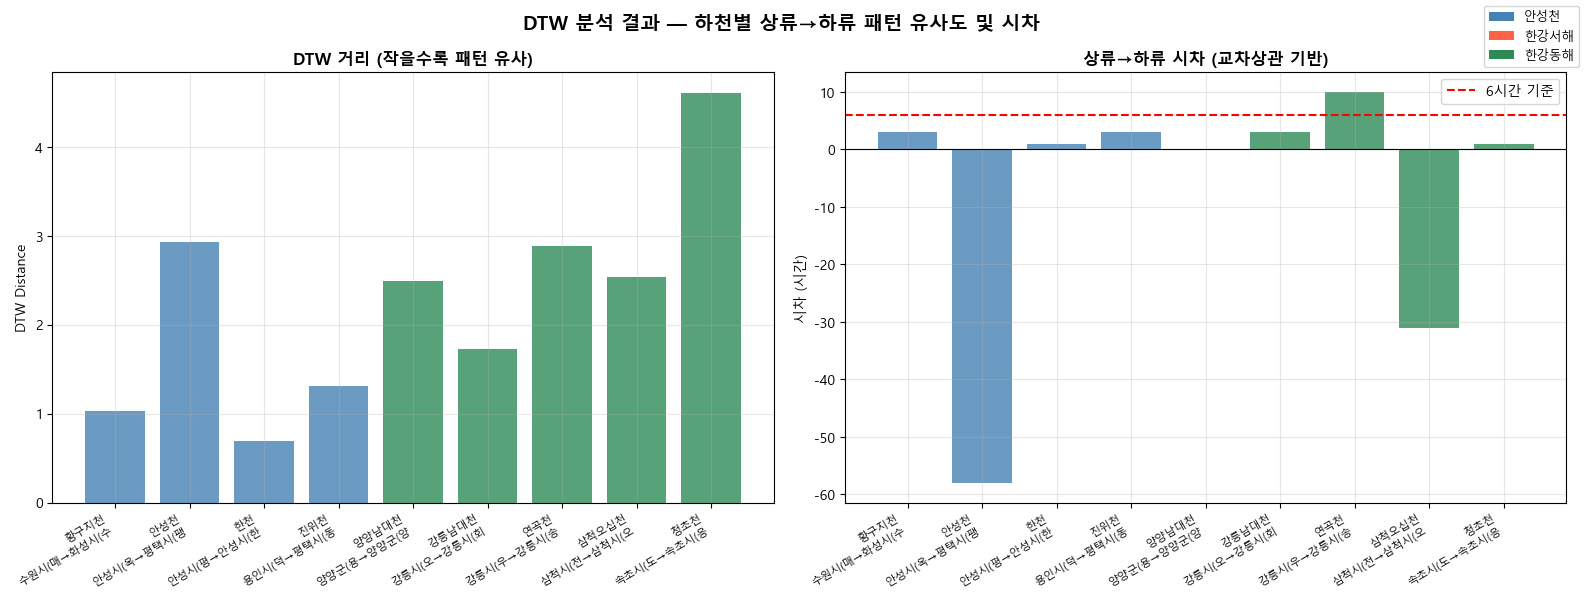


✅ DTW 완료!


In [ ]:
#2024 데이터로만 DTW+교차상관
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from dtaidistance import dtw
from scipy.signal import correlate

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df_24 = pd.read_csv(f'{base}\\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
df_25 = pd.read_csv(f'{base}\\waterlevel_1H_2025_78.csv', encoding='utf-8-sig')
df_1h = pd.concat([df_24, df_25], ignore_index=True)
df_1h['datetime'] = pd.to_datetime(df_1h['datetime'])
df_1h['wl'] = pd.to_numeric(df_1h['wl'], errors='coerce')
df_1h = df_1h.dropna(subset=['wl'])

df_peaks = pd.read_csv(f'{base}\\peak_dates.csv', encoding='utf-8-sig')
df_peaks['peak_datetime'] = pd.to_datetime(df_peaks['peak_datetime'])

# obsFinal merge
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')
stream_map = {
    '평택수위표': '안성천', '동연교수위표': '진위천',
    '안성천상류': '안성천', '황구지천상류': '황구지천',
    '황구지천하류': '황구지천', '아산방조제상류': '안성천',
    '이동댐': '진위천', '삼척오십천상류': '삼척오십천',
    '삼천오십천하류': '삼척오십천',
}
df_meta['korStream_x'] = df_meta['korStream_x'].replace(stream_map)
df_meta['waterElevation'] = pd.to_numeric(df_meta['waterElevation'], errors='coerce')
df_meta['is_special'] = np.where(df_meta['aFLAdvisory(m)'] == '-', 0, 1)

df_1h = df_1h.merge(
    df_meta[['codeObs','korObs','korStream_x','sphereLarge','waterElevation','is_special']],
    left_on='obscd', right_on='codeObs', how='left'
)

# ── DTW 분석 ─────────────────────────────────────────────────────────────────
target_regions = ['안성천', '한강서해', '한강동해']
results = []

for region in target_regions:
    df_region = df_1h[df_1h['sphereLarge'] == region]
    streams = df_region['korStream_x'].dropna().unique()

    for stream in streams:
        df_stream = df_region[df_region['korStream_x'] == stream]

        obs_sorted = (df_meta[df_meta['korStream_x'] == stream]
                      .sort_values('waterElevation', ascending=False)['codeObs'].tolist())
        obs_in_data = [o for o in obs_sorted if o in df_stream['obscd'].values]

        if len(obs_in_data) < 2:
            continue

        ref_obs = obs_in_data[0]   # 상류
        tgt_obs = obs_in_data[-1]  # 하류

        ref_name = df_meta[df_meta['codeObs']==ref_obs]['korObs'].values[0]
        tgt_name = df_meta[df_meta['codeObs']==tgt_obs]['korObs'].values[0]

        dtw_distances = []
        lag_hours_list = []

        for _, pk_row in df_peaks[(df_peaks['obscd'] == ref_obs) & (df_peaks['year'] == 2025)].iterrows():
            peak_dt = pk_row['peak_datetime']
            start_dt = peak_dt - pd.Timedelta(days=3)
            end_dt   = peak_dt + pd.Timedelta(days=5)

            ref_w = (df_stream[df_stream['obscd'] == ref_obs]
                     .set_index('datetime')
                     .reindex(pd.date_range(start_dt, end_dt, freq='1H'))['wl']
                     .interpolate().values)

            tgt_w = (df_stream[df_stream['obscd'] == tgt_obs]
                     .set_index('datetime')
                     .reindex(pd.date_range(start_dt, end_dt, freq='1H'))['wl']
                     .interpolate().values)

            mask = ~(np.isnan(ref_w) | np.isnan(tgt_w))
            ref_s = ref_w[mask].astype(np.float64)
            tgt_s = tgt_w[mask].astype(np.float64)

            if len(ref_s) < 10:
                continue

            # 정규화
            ref_norm = (ref_s - ref_s.min()) / (ref_s.max() - ref_s.min() + 1e-9)
            tgt_norm = (tgt_s - tgt_s.min()) / (tgt_s.max() - tgt_s.min() + 1e-9)

            # DTW 거리 (패턴 유사도)
            dist = dtw.distance(ref_norm, tgt_norm)
            dtw_distances.append(dist)

            # 교차상관으로 시차 계산
            corr = correlate(tgt_s - tgt_s.mean(), ref_s - ref_s.mean(), mode='full')
            lag_steps = corr.argmax() - (len(ref_s) - 1)
            lag_hours_list.append(lag_steps)

        if not dtw_distances:
            continue

        avg_dist = round(np.mean(dtw_distances), 4)
        avg_lag  = round(np.mean(lag_hours_list), 2)

        results.append({
            'region':     region,
            'stream':     stream,
            'upstream':   ref_name,
            'downstream': tgt_name,
            'dtw_dist':   avg_dist,
            'lag_hours':  avg_lag,
            'n_events':   len(dtw_distances),
        })
        print(f"{stream}: {ref_name} → {tgt_name} | DTW거리: {avg_dist} | 시차: {avg_lag}h")

# ── 저장 및 시각화 ────────────────────────────────────────────────────────────
df_result = pd.DataFrame(results)
df_result.to_csv(f'{base}\\dtw_practice.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'안성천': 'steelblue', '한강서해': 'tomato', '한강동해': 'seagreen'}
x = range(len(df_result))

axes[0].bar(x, df_result['dtw_dist'],
            color=[colors.get(r, 'gray') for r in df_result['region']], alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"{r['stream']}\n{r['upstream'][:5]}→{r['downstream'][:5]}"
     for _, r in df_result.iterrows()],
    rotation=30, ha='right', fontsize=8)
axes[0].set_title('DTW 거리 (작을수록 패턴 유사)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('DTW Distance')
axes[0].grid(True, alpha=0.3)

axes[1].bar(x, df_result['lag_hours'],
            color=[colors.get(r, 'gray') for r in df_result['region']], alpha=0.8)
axes[1].axhline(6,  color='red',   linestyle='--', linewidth=1.5, label='6시간 기준')
axes[1].axhline(0,  color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"{r['stream']}\n{r['upstream'][:5]}→{r['downstream'][:5]}"
     for _, r in df_result.iterrows()],
    rotation=30, ha='right', fontsize=8)
axes[1].set_title('상류→하류 시차 (교차상관 기반)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('시차 (시간)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in colors.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('DTW 분석 결과 — 하천별 상류→하류 패턴 유사도 및 시차',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base}\\dtw_practice.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ DTW 완료!")

In [39]:
# DTW 가능/불가 하천 검증
import pandas as pd

base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')

stream_map = {
    '평택수위표': '안성천', '동연교수위표': '진위천',
    '안성천상류': '안성천', '황구지천상류': '황구지천',
    '황구지천하류': '황구지천', '아산방조제상류': '안성천',
    '이동댐': '진위천', '삼척오십천상류': '삼척오십천',
    '삼천오십천하류': '삼척오십천',
}
df_meta['korStream_x'] = df_meta['korStream_x'].replace(stream_map)

target_regions = ['안성천', '한강서해', '한강동해']
df_target = df_meta[df_meta['sphereLarge'].isin(target_regions)]

print("=" * 70)
print("DTW 가능/불가 하천 분류")
print("=" * 70)

dtw_possible = []
dtw_impossible = []

for region in target_regions:
    df_region = df_target[df_target['sphereLarge'] == region]
    streams = df_region['korStream_x'].unique()
    
    print(f"\n[ {region} ]")
    for stream in sorted(streams):
        count = len(df_region[df_region['korStream_x'] == stream])
        status = "DTW 가능" if count >= 2 else "DTW 불가"
        
        if count >= 2:
            dtw_possible.append((region, stream, count))
        else:
            dtw_impossible.append((region, stream, count))
        
        print(f"  {stream:<15} {count}개 관측소 → {status}")

print("\n" + "=" * 70)
print(f"DTW 가능 하천: {len(dtw_possible)}개")
print(f"DTW 불가 하천: {len(dtw_impossible)}개")
print(f"전체 하천: {len(dtw_possible) + len(dtw_impossible)}개")
print("=" * 70)

print("\n[ DTW 불가 하천 상세 ]")
for region, stream, count in dtw_impossible:
    obs_names = df_meta[(df_meta['sphereLarge']==region) & 
                        (df_meta['korStream_x']==stream)]['korObs'].tolist()
    print(f"{region} - {stream}: {obs_names}")

DTW 가능/불가 하천 분류

[ 안성천 ]
  성환천             1개 관측소 → DTW 불가
  안성천             7개 관측소 → DTW 가능
  오산천             1개 관측소 → DTW 불가
  입장천             1개 관측소 → DTW 불가
  진위천             5개 관측소 → DTW 가능
  청룡천             1개 관측소 → DTW 불가
  한천              2개 관측소 → DTW 가능
  황구지천            4개 관측소 → DTW 가능

[ 한강서해 ]
  공촌천             1개 관측소 → DTW 불가
  남양방조제           1개 관측소 → DTW 불가
  삼동암천            1개 관측소 → DTW 불가
  화정천             1개 관측소 → DTW 불가

[ 한강동해 ]
  가곡천             1개 관측소 → DTW 불가
  강릉남대천           2개 관측소 → DTW 가능
  경포천             1개 관측소 → DTW 불가
  북천              1개 관측소 → DTW 불가
  삼척오십천           4개 관측소 → DTW 가능
  양양남대천           2개 관측소 → DTW 가능
  연곡천             2개 관측소 → DTW 가능
  전천              1개 관측소 → DTW 불가
  청초천             2개 관측소 → DTW 가능
  후천              1개 관측소 → DTW 불가

DTW 가능 하천: 9개
DTW 불가 하천: 13개
전체 하천: 22개

[ DTW 불가 하천 상세 ]
안성천 - 성환천: ['천안시(장천교)']
안성천 - 오산천: ['오산시(탑동대교)']
안성천 - 입장천: ['천안시(안궁교)']
안성천 - 청룡천: ['안성시(고지교)']
한강서해 - 공촌천: ['인천시(연수교)']
한강서해 - 남양방조제: ['화성시(발안천2교)

In [27]:
# 2025년 피크 있는 관측소 확인
print(df_peaks[df_peaks['year']==2025].groupby('korStream_x').size())

korStream_x
가곡천      1
강릉남대천    2
경포천      1
공촌천      1
남양방조제    1
북천       1
삼동암천     1
삼척오십천    3
성환천      1
안성천      6
양양남대천    2
연곡천      2
오산천      1
입장천      1
전천       1
진위천      5
청룡천      1
청초천      2
한천       2
화정천      1
황구지천     4
후천       1
dtype: int64


In [40]:
# 하천별 공통 피크 추출 (인접 상-하류가 같은 호우 이벤트를 보도록)
import pandas as pd
import numpy as np

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'

# ── 1H 데이터 로드 ────────────────────────────────────────────────────────────
df_24 = pd.read_csv(f'{base}\\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
df_25 = pd.read_csv(f'{base}\\waterlevel_1H_2025_78.csv', encoding='utf-8-sig')

df_24['year'] = 2024
df_25['year'] = 2025
df_1h = pd.concat([df_24, df_25], ignore_index=True)
df_1h['datetime'] = pd.to_datetime(df_1h['datetime'])
df_1h['wl'] = pd.to_numeric(df_1h['wl'], errors='coerce')
df_1h = df_1h.dropna(subset=['wl'])

# ── obsFinal merge ────────────────────────────────────────────────────────────
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')

stream_map = {
    '평택수위표':    '안성천',
    '동연교수위표':  '진위천',
    '안성천상류':    '안성천',
    '황구지천상류':  '황구지천',
    '황구지천하류':  '황구지천',
    '아산방조제상류': '안성천',
    '이동댐':        '진위천',
    '삼척오십천상류': '삼척오십천',
    '삼천오십천하류': '삼척오십천',
}
df_meta['korStream_x'] = df_meta['korStream_x'].replace(stream_map)
df_meta['waterElevation'] = pd.to_numeric(df_meta['waterElevation'], errors='coerce')
df_meta['is_special'] = np.where(df_meta['aFLAdvisory(m)'] == '-', 0, 1)

df_1h = df_1h.merge(
    df_meta[['codeObs','korObs','korStream_x','sphereLarge','waterElevation','is_special']],
    left_on='obscd', right_on='codeObs', how='left'
)

# ── 하천별 공통 피크 탐지 ─────────────────────────────────────────────────────
N_EVENTS_PER_YEAR = 5     # 연도별 하천별 최대 이벤트 수
MIN_NORM_THRESHOLD = 0.5  # 정규화 수위 이 값 미만은 호우 아님
MIN_DAYS_GAP = 2          # 같은 호우의 연속된 날 제외 (±N일)

stream_peak_records = []

for (year, stream), df_s in df_1h.groupby(['year', 'korStream_x']):
    if df_s.empty or pd.isna(stream):
        continue

    # 관측소별 정규화 (스케일 차이 제거)
    df_s = df_s.copy()
    df_s['wl_norm'] = df_s.groupby('obscd')['wl'].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
    )

    # 같은 시각 모든 관측소의 정규화 수위 평균 → 하천 대표 시계열
    stream_ts = df_s.groupby('datetime')['wl_norm'].mean()

    # 일별 최댓값 → 큰 순서로 정렬
    daily_max = stream_ts.resample('D').max().sort_values(ascending=False)
    daily_max = daily_max[daily_max >= MIN_NORM_THRESHOLD]  # 호우 임계 필터

    # 이벤트 분리 (이미 뽑은 날 ±N일은 제외)
    top_days = []
    for day in daily_max.index:
        if all(abs((day - d).days) > MIN_DAYS_GAP for d in top_days):
            top_days.append(day)
        if len(top_days) >= N_EVENTS_PER_YEAR:
            break

    # 각 피크일에 대해 하천 내 모든 관측소의 그날 피크 시각/수위 기록
    for event_idx, peak_day in enumerate(sorted(top_days), start=1):
        day_start = peak_day
        day_end   = peak_day + pd.Timedelta(days=1)
        df_day = df_s[(df_s['datetime'] >= day_start) & (df_s['datetime'] < day_end)]

        for obscd, df_obs in df_day.groupby('obscd'):
            if df_obs.empty:
                continue
            peak_idx = df_obs['wl'].idxmax()
            row = df_obs.loc[peak_idx]
            stream_peak_records.append({
                'year':            year,
                'event_id':        f"{stream}_{year}_{event_idx}",
                'event_date':      peak_day.date(),
                'obscd':           obscd,
                'korObs':          row['korObs'],
                'korStream_x':     stream,
                'sphereLarge':     row['sphereLarge'],
                'waterElevation':  row['waterElevation'],
                'is_special':      row['is_special'],
                'peak_datetime':   row['datetime'],
                'peak_wl':         row['wl'],
            })

df_peaks_stream = pd.DataFrame(stream_peak_records)
df_peaks_stream = df_peaks_stream.sort_values(
    ['sphereLarge','korStream_x','event_date','waterElevation'],
    ascending=[True,True,True,False]
).reset_index(drop=True)

# ── 저장 ──────────────────────────────────────────────────────────────────────
save_path = f'{base}\\peak_dates_by_stream.csv'
df_peaks_stream.to_csv(save_path, index=False, encoding='utf-8-sig')

# ── 요약 출력 ─────────────────────────────────────────────────────────────────
print("=" * 70)
print("하천별 공통 피크 추출 결과")
print("=" * 70)
print(f"전체 레코드: {len(df_peaks_stream):,}건")
print(f"고유 이벤트: {df_peaks_stream['event_id'].nunique()}개")
print(f"저장 경로: {save_path}\n")

print("[ 하천별 이벤트 수 ]")
event_summary = (df_peaks_stream.groupby(['sphereLarge','korStream_x','year'])['event_id']
                 .nunique().reset_index(name='n_events'))
print(event_summary.to_string(index=False))

print("\n✅ 하천별 피크 추출 완료!")

하천별 공통 피크 추출 결과
전체 레코드: 157건
고유 이벤트: 97개
저장 경로: C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\peak_dates_by_stream.csv

[ 하천별 이벤트 수 ]
sphereLarge korStream_x  year  n_events
        안성천         성환천  2025         1
        안성천         안성천  2024         2
        안성천         안성천  2025         1
        안성천         오산천  2024         1
        안성천         오산천  2025         2
        안성천         입장천  2024         2
        안성천         입장천  2025         1
        안성천         진위천  2024         1
        안성천         진위천  2025         2
        안성천         청룡천  2025         1
        안성천          한천  2024         2
        안성천          한천  2025         1
        안성천        황구지천  2024         1
        안성천        황구지천  2025         3
       한강동해         가곡천  2024         1
       한강동해         가곡천  2025         5
       한강동해       강릉남대천  2024         1
       한강동해       강릉남대천  2025         2
       한강동해         경포천  2025         3
       한강동해          북천  2025         5
       한강동해       삼척오

황구지천: 수원시(매세교) → 수원시(백년교) | DTW(med): 0.883 | lag(med): 0.0h | n=3(+3)
황구지천: 수원시(백년교) → 화성시(화산교) | DTW(med): 0.692 | lag(med): 1.0h | n=3(+3)
황구지천: 화성시(화산교) → 화성시(수직교) | DTW(med): 0.467 | lag(med): 2.0h | n=4(+4)
안성천: 안성시(옥산대교) → 안성시(건천리) | DTW(med): 0.271 | lag(med): 0.0h | n=3(+3)
안성천: 안성시(건천리) → 천안시(안성천교) | DTW(med): 0.241 | lag(med): 1.0h | n=3(+3)
안성천: 천안시(안성천교) → 아산시(운교교) | DTW(med): 0.459 | lag(med): -3.0h | n=1(+0)
안성천: 아산시(운교교) → 평택시(군문교) | DTW(med): 0.677 | lag(med): 3.0h | n=1(+1)
안성천: 평택시(군문교) → 평택시(팽성대교) | DTW(med): 1.158 | lag(med): 1.0h | n=3(+3)
한천: 안성시(평촌교) → 안성시(한천교) | DTW(med): 0.505 | lag(med): 1.0h | n=1(+1)
진위천: 용인시(덕성1교) → 용인시(전궁교) | DTW(med): 1.227 | lag(med): -0.5h | n=2(+1)
진위천: 용인시(전궁교) → 평택시(진위1교) | DTW(med): 0.461 | lag(med): 1.0h | n=2(+2)
진위천: 평택시(진위1교) → 평택시(회화리) | DTW(med): 0.314 | lag(med): 1.0h | n=3(+3)
진위천: 평택시(회화리) → 평택시(동연교) | DTW(med): 0.465 | lag(med): 0.0h | n=3(+3)
양양남대천: 양양군(용천2교) → 양양군(양양대교) | DTW(med): 0.932 | lag(med): 0.0h | n=5(+4)
강릉남대천

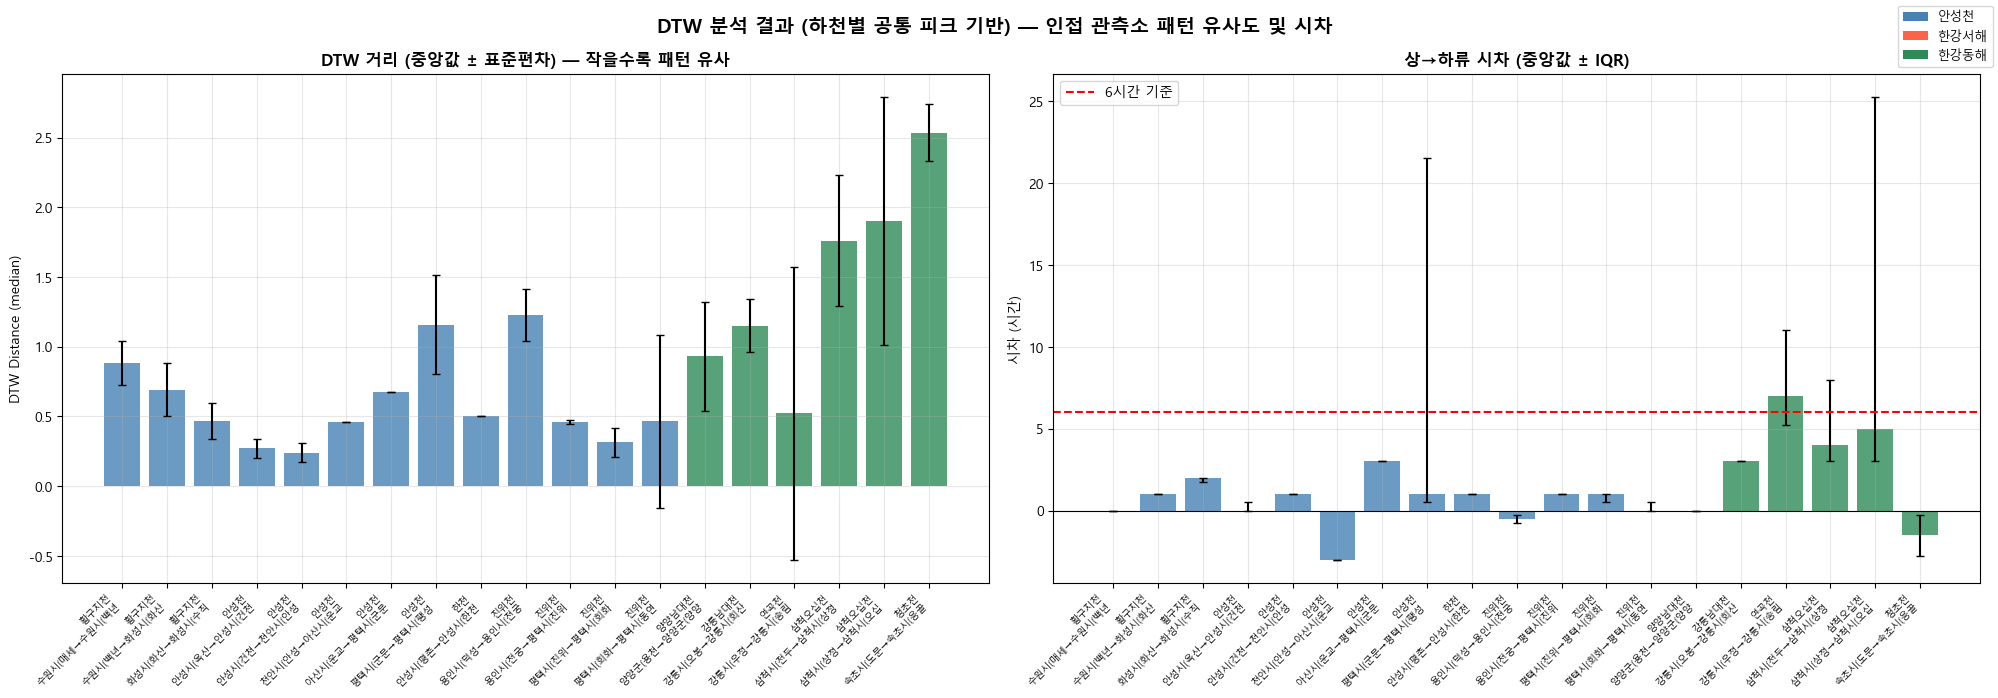


DTW 분석 완료 (하천별 공통 피크)
인접 관측소 쌍: 19개
이벤트 단위 기록: 58건

저장 파일:
  - dtw_result_by_stream.csv  (쌍별 통계)
  - dtw_events_by_stream.csv  (이벤트별 상세)
  - dtw_result_by_stream.png  (시각화)


In [41]:
# 하천별 공통 피크 기반 DTW + 교차상관 (인접 관측소 비교)
# - peak_dates_by_stream.csv 사용
# - 같은 event_id를 공유하는 ref/tgt 쌍만 비교
# - 윈도우: peak -1일 ~ +2일 (단일 호우 이벤트만)
# - 통계: median + IQR + 양수 시차 필터링
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Patch
from dtaidistance import dtw
from scipy.signal import correlate

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df_24 = pd.read_csv(f'{base}\\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
df_25 = pd.read_csv(f'{base}\\waterlevel_1H_2025_78.csv', encoding='utf-8-sig')
df_1h = pd.concat([df_24, df_25], ignore_index=True)
df_1h['datetime'] = pd.to_datetime(df_1h['datetime'])
df_1h['wl'] = pd.to_numeric(df_1h['wl'], errors='coerce')
df_1h = df_1h.dropna(subset=['wl'])

# 하천별 피크 (새 버전)
df_peaks = pd.read_csv(f'{base}\\peak_dates_by_stream.csv', encoding='utf-8-sig')
df_peaks['peak_datetime'] = pd.to_datetime(df_peaks['peak_datetime'])

# obsFinal merge
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')
stream_map = {
    '평택수위표': '안성천', '동연교수위표': '진위천',
    '안성천상류': '안성천', '황구지천상류': '황구지천',
    '황구지천하류': '황구지천', '아산방조제상류': '안성천',
    '이동댐': '진위천', '삼척오십천상류': '삼척오십천',
    '삼천오십천하류': '삼척오십천',
}
df_meta['korStream_x'] = df_meta['korStream_x'].replace(stream_map)
df_meta['waterElevation'] = pd.to_numeric(df_meta['waterElevation'], errors='coerce')
df_meta['is_special'] = np.where(df_meta['aFLAdvisory(m)'] == '-', 0, 1)

df_1h = df_1h.merge(
    df_meta[['codeObs','korObs','korStream_x','sphereLarge','waterElevation','is_special']],
    left_on='obscd', right_on='codeObs', how='left'
)

# ── DTW 분석 (인접 관측소 + 하천별 공통 이벤트) ──────────────────────────────
target_regions = ['안성천', '한강서해', '한강동해']
WINDOW_BEFORE = pd.Timedelta(days=1)   # 피크 -1일
WINDOW_AFTER  = pd.Timedelta(days=2)   # 피크 +2일

results = []
event_level_records = []  # 이벤트 단위 상세 기록

for region in target_regions:
    df_region = df_1h[df_1h['sphereLarge'] == region]
    streams = df_region['korStream_x'].dropna().unique()

    for stream in streams:
        df_stream = df_region[df_region['korStream_x'] == stream]

        # 해발고도 기준 상→하류 정렬
        obs_sorted = (df_meta[df_meta['korStream_x'] == stream]
                      .sort_values('waterElevation', ascending=False)['codeObs'].tolist())
        obs_in_data = [o for o in obs_sorted if o in df_stream['obscd'].values]

        if len(obs_in_data) < 2:
            continue

        # 인접 관측소끼리 비교
        for i in range(len(obs_in_data) - 1):
            ref_obs = obs_in_data[i]      # 상류
            tgt_obs = obs_in_data[i + 1]  # 바로 아래 하류

            ref_name = df_meta[df_meta['codeObs']==ref_obs]['korObs'].values[0]
            tgt_name = df_meta[df_meta['codeObs']==tgt_obs]['korObs'].values[0]

            # 같은 event_id에 ref/tgt 둘 다 피크 있는 이벤트만 추출
            events_in_stream = df_peaks[df_peaks['korStream_x'] == stream]['event_id'].unique()

            dtw_distances = []
            lag_hours_list = []
            event_ids_used = []

            for event_id in events_in_stream:
                ref_peak = df_peaks[(df_peaks['obscd']==ref_obs) &
                                    (df_peaks['event_id']==event_id)]
                tgt_peak = df_peaks[(df_peaks['obscd']==tgt_obs) &
                                    (df_peaks['event_id']==event_id)]

                if ref_peak.empty or tgt_peak.empty:
                    continue  # 둘 다 있어야 같은 호우 비교

                # 상류 피크 시각 기준으로 윈도우 잡음 (-1일 ~ +2일)
                peak_dt = ref_peak['peak_datetime'].iloc[0]
                start_dt = peak_dt - WINDOW_BEFORE
                end_dt   = peak_dt + WINDOW_AFTER

                ref_w = (df_stream[df_stream['obscd'] == ref_obs]
                         .set_index('datetime')
                         .reindex(pd.date_range(start_dt, end_dt, freq='1H'))['wl']
                         .interpolate().values)

                tgt_w = (df_stream[df_stream['obscd'] == tgt_obs]
                         .set_index('datetime')
                         .reindex(pd.date_range(start_dt, end_dt, freq='1H'))['wl']
                         .interpolate().values)

                mask = ~(np.isnan(ref_w) | np.isnan(tgt_w))
                ref_s = ref_w[mask].astype(np.float64)
                tgt_s = tgt_w[mask].astype(np.float64)

                if len(ref_s) < 10:
                    continue

                # 정규화
                ref_norm = (ref_s - ref_s.min()) / (ref_s.max() - ref_s.min() + 1e-9)
                tgt_norm = (tgt_s - tgt_s.min()) / (tgt_s.max() - tgt_s.min() + 1e-9)

                # DTW 거리
                dist = dtw.distance(ref_norm, tgt_norm)

                # 교차상관 시차 (양수면 하류가 늦게 피크)
                corr = correlate(tgt_s - tgt_s.mean(), ref_s - ref_s.mean(), mode='full')
                lag_steps = corr.argmax() - (len(ref_s) - 1)

                dtw_distances.append(dist)
                lag_hours_list.append(lag_steps)
                event_ids_used.append(event_id)

                # 이벤트 단위 기록
                event_level_records.append({
                    'region':     region,
                    'stream':     stream,
                    'event_id':   event_id,
                    'upstream':   ref_name,
                    'downstream': tgt_name,
                    'dtw_dist':   round(dist, 4),
                    'lag_hours':  lag_steps,
                })

            if not dtw_distances:
                continue

            arr_dtw = np.array(dtw_distances)
            arr_lag = np.array(lag_hours_list)

            # 양수 시차만 (물리적으로 유효한 이벤트)
            arr_lag_pos = arr_lag[arr_lag >= 0]
            n_positive = len(arr_lag_pos)
            n_total    = len(arr_lag)

            results.append({
                'region':       region,
                'stream':       stream,
                'upstream':     ref_name,
                'downstream':   tgt_name,
                # DTW 거리 통계
                'dtw_median':   round(np.median(arr_dtw), 4),
                'dtw_mean':     round(np.mean(arr_dtw), 4),
                'dtw_std':      round(np.std(arr_dtw), 4),
                # 시차 통계 (전체)
                'lag_median':   round(np.median(arr_lag), 2),
                'lag_mean':     round(np.mean(arr_lag), 2),
                'lag_std':      round(np.std(arr_lag), 2),
                'lag_q25':      round(np.percentile(arr_lag, 25), 2),
                'lag_q75':      round(np.percentile(arr_lag, 75), 2),
                # 시차 통계 (양수만 — 신뢰 가능)
                'lag_median_positive': round(np.median(arr_lag_pos), 2) if n_positive >= 3 else np.nan,
                'lag_std_positive':    round(np.std(arr_lag_pos), 2)    if n_positive >= 3 else np.nan,
                # 표본 정보
                'n_events':       n_total,
                'n_events_positive': n_positive,
            })

            print(f"{stream}: {ref_name} → {tgt_name} | "
                  f"DTW(med): {np.median(arr_dtw):.3f} | "
                  f"lag(med): {np.median(arr_lag):.1f}h | "
                  f"n={n_total}(+{n_positive})")

# ── 저장 ──────────────────────────────────────────────────────────────────────
df_result = pd.DataFrame(results)
df_event  = pd.DataFrame(event_level_records)

df_result.to_csv(f'{base}\\dtw_result_by_stream.csv', index=False, encoding='utf-8-sig')
df_event.to_csv (f'{base}\\dtw_events_by_stream.csv', index=False, encoding='utf-8-sig')

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
colors = {'안성천': 'steelblue', '한강서해': 'tomato', '한강동해': 'seagreen'}
x = range(len(df_result))

# DTW 거리 (median) + std 에러바
axes[0].bar(x, df_result['dtw_median'],
            yerr=df_result['dtw_std'],
            color=[colors.get(r, 'gray') for r in df_result['region']],
            alpha=0.8, capsize=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"{r['stream']}\n{r['upstream'][:6]}→{r['downstream'][:6]}"
     for _, r in df_result.iterrows()],
    rotation=45, ha='right', fontsize=7)
axes[0].set_title('DTW 거리 (중앙값 ± 표준편차) — 작을수록 패턴 유사',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('DTW Distance (median)')
axes[0].grid(True, alpha=0.3)

# 시차 (median) + IQR 에러바
lag_err_lower = df_result['lag_median'] - df_result['lag_q25']
lag_err_upper = df_result['lag_q75']    - df_result['lag_median']

axes[1].bar(x, df_result['lag_median'],
            yerr=[lag_err_lower, lag_err_upper],
            color=[colors.get(r, 'gray') for r in df_result['region']],
            alpha=0.8, capsize=3)
axes[1].axhline(6,  color='red',   linestyle='--', linewidth=1.5, label='6시간 기준')
axes[1].axhline(0,  color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"{r['stream']}\n{r['upstream'][:6]}→{r['downstream'][:6]}"
     for _, r in df_result.iterrows()],
    rotation=45, ha='right', fontsize=7)
axes[1].set_title('상→하류 시차 (중앙값 ± IQR)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('시차 (시간)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

legend_elements = [Patch(facecolor=c, label=r) for r, c in colors.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('DTW 분석 결과 (하천별 공통 피크 기반) — 인접 관측소 패턴 유사도 및 시차',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base}\\dtw_result_by_stream.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("DTW 분석 완료 (하천별 공통 피크)")
print("="*70)
print(f"인접 관측소 쌍: {len(df_result)}개")
print(f"이벤트 단위 기록: {len(df_event)}건")
print(f"\n저장 파일:")
print(f"  - dtw_result_by_stream.csv  (쌍별 통계)")
print(f"  - dtw_events_by_stream.csv  (이벤트별 상세)")
print(f"  - dtw_result_by_stream.png  (시각화)")

In [42]:
# peak_dates_by_stream에서 ref/tgt가 공유하는 event_id 개수 보기
ref_obs = '...'
tgt_obs = '...'
ref_events = set(df_peaks[df_peaks['obscd']==ref_obs]['event_id'])
tgt_events = set(df_peaks[df_peaks['obscd']==tgt_obs]['event_id'])
print(f"공통 이벤트: {len(ref_events & tgt_events)}")
print(f"ref만: {ref_events - tgt_events}")
print(f"tgt만: {tgt_events - ref_events}")

공통 이벤트: 0
ref만: set()
tgt만: set()


In [43]:
import pandas as pd

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
df_peaks = pd.read_csv(f'{base}\\peak_dates_by_stream.csv', encoding='utf-8-sig')

# 안성천교, 운교교 obscd 확인
target_names = ['천안시(안성천교)', '아산시(운교교)']
print(df_peaks[df_peaks['korObs'].isin(target_names)][
    ['event_id','event_date','obscd','korObs','peak_datetime','peak_wl']
].sort_values(['event_date','korObs']).to_string())

      event_id  event_date    obscd     korObs        peak_datetime  peak_wl
3   안성천_2024_1  2024-07-09  1101630  천안시(안성천교)  2024-07-09 01:00:00     3.05
8   안성천_2024_2  2024-07-18  1101630  천안시(안성천교)  2024-07-18 16:00:00     4.22
14  안성천_2025_1  2025-07-17  1101688   아산시(운교교)  2025-07-17 07:00:00     6.30
13  안성천_2025_1  2025-07-17  1101630  천안시(안성천교)  2025-07-17 10:00:00     4.96


In [44]:
target_obs = ['1101610', '1101620']  # 현수교, 마차교 codeObs는 obsFinal에서 확인
print("현수교 데이터:", len(df_1h[df_1h['korObs']=='안성시(현수교)']))
print("마차교 데이터:", len(df_1h[df_1h['korObs']=='삼척시(마차교)']))

현수교 데이터: 0
마차교 데이터: 0


In [46]:
import pandas as pd
base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'
df = pd.read_csv(f'{base}\\obsFinal.csv', encoding='cp949')
target = df[df['korObs'].isin(['안성시(현수교)','삼척시(마차교)'])]
print(target[['korObs','codeObs','sphereLarge']])

      korObs  codeObs sphereLarge
57  삼척시(마차교)  1303645        한강동해
91  안성시(현수교)  1101606         안성천


In [47]:
import pandas as pd

base = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl'
df_24 = pd.read_csv(f'{base}\\waterlevel_1H_2024_78.csv', encoding='utf-8-sig')
df_25 = pd.read_csv(f'{base}\\waterlevel_1H_2025_78.csv', encoding='utf-8-sig')

base_meta = r'C:\Users\안서영\Desktop\hangang\HanRiver_FloodControl\waterlevel_pre_final'
df_meta = pd.read_csv(f'{base_meta}\\obsFinal.csv', encoding='cp949')

# 본인 권역 관측소
target_meta = df_meta[df_meta['sphereLarge'].isin(['안성천','한강서해','한강동해'])]

# 데이터 있는 관측소
obscd_24 = set(df_24['obscd'].unique())
obscd_25 = set(df_25['obscd'].unique())

# 누락 점검
target_meta['has_2024'] = target_meta['codeObs'].isin(obscd_24)
target_meta['has_2025'] = target_meta['codeObs'].isin(obscd_25)

# 둘 다 없는 곳 (= 분석 완전 불가)
missing = target_meta[~target_meta['has_2024'] & ~target_meta['has_2025']]
print("="*60)
print("데이터 완전 누락 관측소")
print("="*60)
print(missing[['korObs','korStream_x','sphereLarge','inOperation','methodObs']])

# 한쪽만 있는 곳 (운교교 같은 케이스)
partial = target_meta[
    (target_meta['has_2024'] != target_meta['has_2025'])
]
print("\n" + "="*60)
print("일부 연도만 데이터 있는 관측소")
print("="*60)
print(partial[['korObs','korStream_x','has_2024','has_2025']])

데이터 완전 누락 관측소
      korObs korStream_x sphereLarge inOperation methodObs
57  삼척시(마차교)     삼척오십천상류        한강동해          운영       T/M
91  안성시(현수교)       안성천상류         안성천          운영       T/M

일부 연도만 데이터 있는 관측소
         korObs korStream_x  has_2024  has_2025
10     강릉시(난곡교)         경포천     False      True
12     강릉시(오봉교)       강릉남대천     False      True
13     강릉시(우정교)         연곡천     False      True
18     고성군(간촌교)          북천     False      True
60    삼척시(전두3교)     삼척오십천상류     False      True
78     속초시(도문교)         청초천     False      True
79     속초시(응골교)         청초천     False      True
80     수원시(매세교)      황구지천상류     False      True
81     수원시(백년교)      황구지천상류     False      True
82     아산시(운교교)       평택수위표     False      True
83   안산시(안산10교)         화정천     False      True
85     안성시(고지교)         청룡천     False      True
88     안성시(평촌교)          한천     False      True
143   용인시(덕성1교)         이동댐     False      True
146    용인시(전궁교)      동연교수위표     False      True
180    인천시(연수교)       